In [1]:
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from utils.evaluation import evaluate_pipeline
from utils import column_type_split, feature_importance_df
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv("../data/train_clear.csv")

In [3]:
target = "Liver_Disease_Type"
X = df.drop(columns=[target])
y = df[target]

In [4]:
columns = column_type_split(X)

In [5]:
pipeline_ohe = Pipeline([
    (
            "preprocess",
            ColumnTransformer(
                [
                    ("ohe", OneHotEncoder(drop="first"), columns.categorical),
                ],
                remainder="passthrough",
            ),
        ),
    ("knn", KNeighborsClassifier())
])

Модель KNeighborsClassifier
F1-macro: 0.496 ± 0.002
F1-weighted: 0.587 ± 0.002


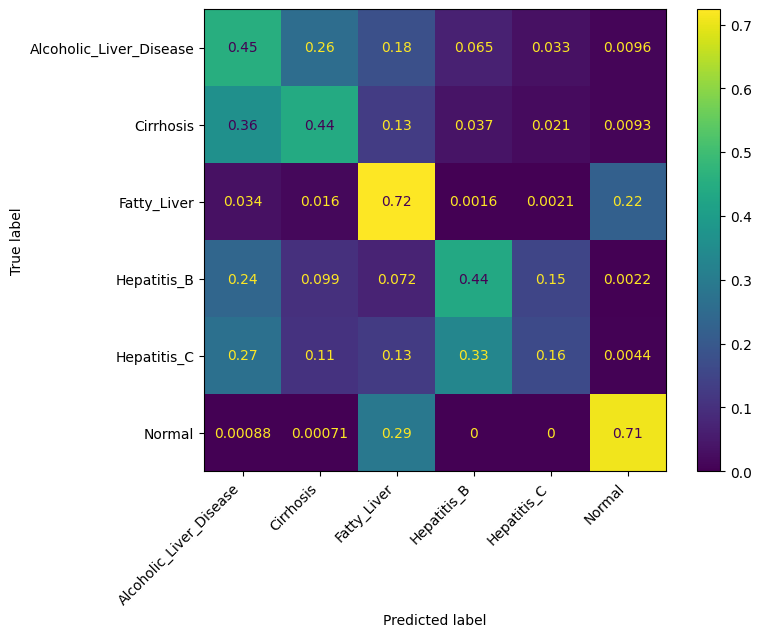

In [6]:
evaluate_pipeline(pipeline_ohe, X, y)

Плохой подход, OneHot создает большое число признаков и из-за проклятия размерности все расстояния стремятся к одному значению - точность низкая\
Для корректной работы KNN лучше использовать меньше признаков. Использованы признаки, вошедшие в топ 10 по важности у логистической регрессии

In [7]:
important_features = [
    "AST",
    "Sym_Jaundice",
    "Bilirubin",
    "ALT",
    "Sym_Ascites",
    "Sym_Itching",
    "Comorb_Diabetes",
    "Sym_Dark_Urine",
    "Sym_Fatigue",
    "Comorb_Genetic_History"
]

In [8]:
pipeline_model_only = Pipeline([
    ("knn", KNeighborsClassifier())
])

Модель KNeighborsClassifier
F1-macro: 0.610 ± 0.003
F1-weighted: 0.719 ± 0.002


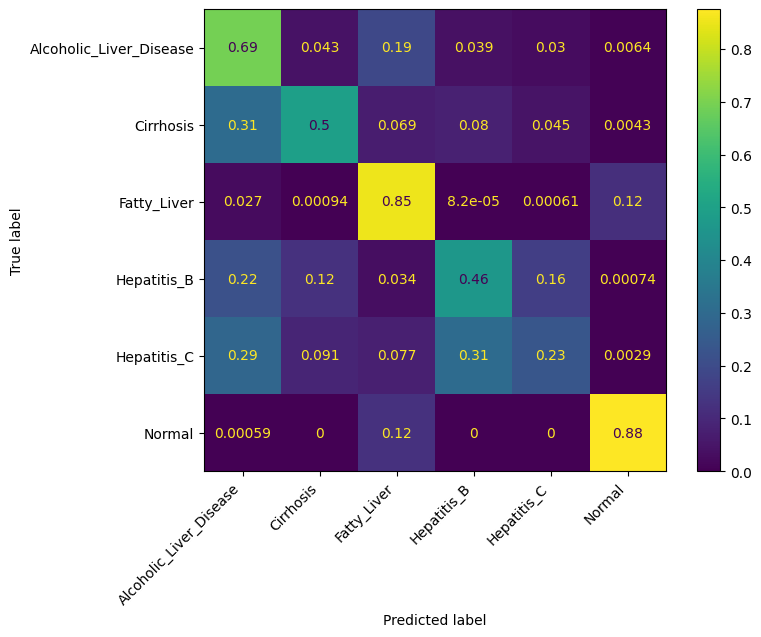

In [9]:
evaluate_pipeline(pipeline_model_only, X[important_features], y)

Использование меньшего количества признаков уже дало улучшение точности. Для улучшения качества необходимо масштабирование - тогда расстояние между объектами будет максимально точно показывать их схожесть

In [10]:
pipeline_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

Модель KNeighborsClassifier
F1-macro: 0.688 ± 0.004
F1-weighted: 0.774 ± 0.004


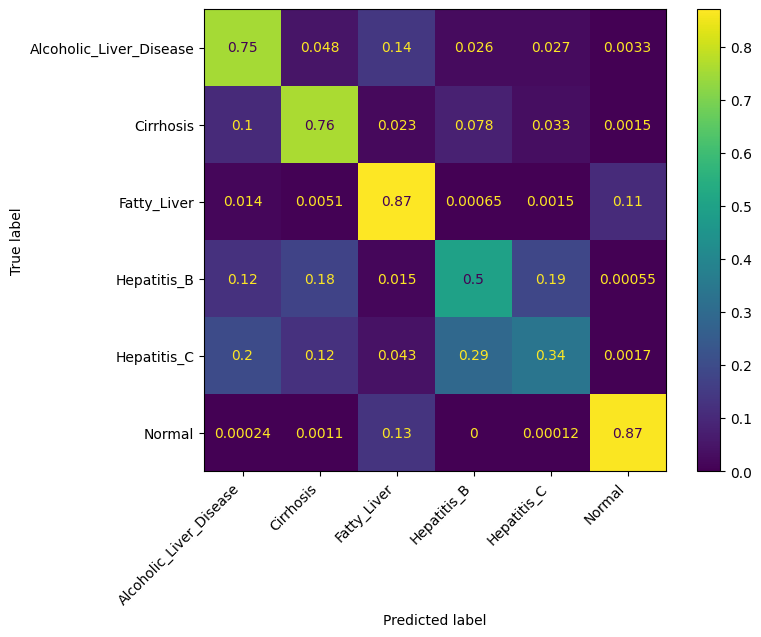

In [11]:
evaluate_pipeline(pipeline_scaled, X[important_features], y)

Масштабированные данные дали высокую точность